# MediumCNN vs ResNet50 Transfer Learning
Compare custom MediumCNN (~15M params) with ResNet50 transfer learning to beat SmallVGG's 69.8% accuracy.

In [1]:
# Block 1: Imports & Config
import os, time, math, copy
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.amp import autocast, GradScaler
from sklearn.metrics import classification_report, confusion_matrix

# ==== CONFIG ====
DATA_MODE = "folders"   # using folder layout
IMAGE_ROOT = "../data"
TRAIN_DIR = os.path.join(IMAGE_ROOT, "train")
TEST_DIR  = os.path.join(IMAGE_ROOT, "test")
OUTPUT_DIR = "./results/medium_cnn_resnet50_contrasted"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_CLASSES   = 7
BATCH_SIZE    = 128
NUM_WORKERS   = 0  # Set to 0 for GPU training
EPOCHS        = 150
BASE_LR       = 0.001  # Lower LR for transfer learning
WEIGHT_DECAY  = 1e-4
MOMENTUM      = 0.9
DROPOUT_PROB  = 0.4  # Slightly reduced dropout

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda:0


In [2]:
# Block 2: Dataset & Augmentations
from torchvision.transforms import RandomErasing

class ImageFolderGray(Dataset):
    """Reads grayscale images from folder layout."""
    def __init__(self, root, transform=None):
        self.samples = []
        self.classes = sorted([d.name for d in Path(root).iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        for c in self.classes:
            for f in (Path(root) / c).glob("*"):
                if f.suffix.lower() in [".png", ".jpg", ".jpeg", ".bmp"]:
                    self.samples.append((str(f), self.class_to_idx[c]))
        self.transform = transform

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, label = self.samples[idx]
        img = Image.open(p).convert("L")
        if self.transform: img = self.transform(img)
        return img, label

# ==== Augmentations ====
train_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=10, translate=(0.2,0.2), scale=(0.8,1.2))
    ], p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(contrast=0.3)  # Adjust contrast by ±30%
    ], p=0.5),
    transforms.RandomCrop(40),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5]),
    RandomErasing(p=0.3)  # Reduced from 0.5
])

val_transform = transforms.Compose([
    transforms.Resize((48,48)),
    transforms.CenterCrop(40),
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# Create datasets
train_ds = ImageFolderGray(TRAIN_DIR, transform=train_transform)
val_ds = ImageFolderGray(TEST_DIR, transform=val_transform)

print(f"✓ Train dataset: {len(train_ds)} images")
print(f"✓ Val dataset: {len(val_ds)} images")
print(f"✓ Classes: {train_ds.classes}")

✓ Train dataset: 28709 images
✓ Val dataset: 7178 images
✓ Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [3]:
# Block 3: Dataloaders
def get_dataloaders(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=False)
    return train_loader, val_loader

train_loader, val_loader = get_dataloaders()
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 225 | Val batches: 57


In [4]:
# Block 4: MediumCNN Architecture (~15M parameters)
class MediumCNN(nn.Module):
    """Medium-sized custom CNN with better capacity than SmallVGG."""
    def __init__(self, num_classes=NUM_CLASSES, dropout_prob=DROPOUT_PROB):
        super().__init__()
        # 5 convolutional blocks (vs 4 in SmallVGG), more channels
        self.features = nn.Sequential(
            # Block 1: 1 -> 64
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(64),
            nn.MaxPool2d(2),  # 48 -> 24

            # Block 2: 64 -> 128
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(128),
            nn.MaxPool2d(2),  # 24 -> 12

            # Block 3: 128 -> 256
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(256),  # Extra conv
            nn.MaxPool2d(2),  # 12 -> 6

            # Block 4: 256 -> 512
            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(512),  # Extra conv
            nn.MaxPool2d(2),  # 6 -> 3

            # Block 5: 512 feature extraction
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(512),
            nn.AdaptiveAvgPool2d((2, 2)),  # 3 -> 2
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512*2*2, 1024), nn.ReLU(True), nn.BatchNorm1d(1024), nn.Dropout(dropout_prob),
            nn.Linear(1024, 512), nn.ReLU(True), nn.BatchNorm1d(512), nn.Dropout(dropout_prob),
            nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(dropout_prob),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Test MediumCNN
model_test = MediumCNN(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"✓ MediumCNN total parameters: {total_params:,}")
del model_test

✓ MediumCNN total parameters: 12,759,495


In [5]:
# Block 5: ResNet50 Transfer Learning
class ResNet50Transfer(nn.Module):
    """ResNet50 with transfer learning from ImageNet."""
    def __init__(self, num_classes=NUM_CLASSES, freeze_backbone=False):
        super().__init__()
        # Load pretrained ResNet50
        self.backbone = models.resnet50(pretrained=True)
        
        # Modify first layer to accept grayscale input (1 channel -> 3 channels via repetition)
        original_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # Copy weights from original conv1 (average the 3 input channels)
        with torch.no_grad():
            self.backbone.conv1.weight[:, 0, :, :] = original_conv.weight.mean(dim=1)
        
        # Replace final FC layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
        # Optionally freeze backbone
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            # Unfreeze last layer
            for param in self.backbone.fc.parameters():
                param.requires_grad = True

    def forward(self, x):
        return self.backbone(x)

# Test ResNet50
model_test = ResNet50Transfer(num_classes=NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"✓ ResNet50 total parameters: {total_params:,}")
del model_test

c:\Users\Yasmine Sassi\miniconda3\envs\pytorch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Yasmine Sassi\miniconda3\envs\pytorch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✓ ResNet50 total parameters: 24,554,439


In [6]:
# Block 6: Training Utilities
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, total_acc, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(outputs, labels) * bs
        n += bs
    return total_loss/n, total_acc/n

def validate(model, loader, criterion):
    model.eval()
    total_loss, total_acc, n = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast(device_type='cuda'):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            bs = imgs.size(0)
            total_loss += loss.item() * bs
            total_acc  += accuracy_from_logits(outputs, labels) * bs
            n += bs
    return total_loss/n, total_acc/n

In [9]:
# Block 7: Training Loop
def fit(model, train_loader, val_loader, model_name="model", epochs=EPOCHS):
    model = model.to(DEVICE)
    print(f"\n{'='*60}")
    print(f"🚀 Training {model_name}")
    print(f"{'='*60}")
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)
    scaler = GradScaler('cuda:0')

    best_val = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc = validate(model, val_loader, criterion)
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        
        print(f"Epoch {epoch+1:2d}/{epochs} | Loss {train_loss:.4f}/{val_loss:.4f} | Acc {train_acc:.4f}/{val_acc:.4f} | {time.time()-t0:.1f}s")

        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f"{model_name}_best.pth"))

    print(f"\n✅ Best Val Acc: {max(history['val_acc']):.4f}")
    return model, history

In [10]:
# Block 8: Train MediumCNN
model_medium = MediumCNN(num_classes=NUM_CLASSES).to(DEVICE)
model_medium, history_medium = fit(model_medium, train_loader, val_loader, 
                                    model_name="MediumCNN", epochs=EPOCHS)


🚀 Training MediumCNN
Epoch  1/150 | Loss 1.8427/1.8011 | Acc 0.2291/0.2357 | 72.6s
Epoch  2/150 | Loss 1.7966/1.7141 | Acc 0.2485/0.3009 | 42.5s
Epoch  3/150 | Loss 1.6556/1.5236 | Acc 0.3325/0.4131 | 42.2s
Epoch  4/150 | Loss 1.5040/1.3287 | Acc 0.4080/0.4915 | 42.3s
Epoch  5/150 | Loss 1.3997/1.2741 | Acc 0.4580/0.5065 | 42.5s
Epoch  6/150 | Loss 1.3290/1.1821 | Acc 0.4897/0.5433 | 42.5s
Epoch  7/150 | Loss 1.2794/1.2323 | Acc 0.5164/0.5326 | 42.6s
Epoch  8/150 | Loss 1.2464/1.1292 | Acc 0.5272/0.5609 | 42.4s
Epoch  9/150 | Loss 1.2279/1.1065 | Acc 0.5359/0.5841 | 42.3s
Epoch 10/150 | Loss 1.2084/1.0883 | Acc 0.5441/0.5932 | 42.5s
Epoch 11/150 | Loss 1.1900/1.1064 | Acc 0.5547/0.5830 | 42.6s
Epoch 12/150 | Loss 1.1782/1.0694 | Acc 0.5618/0.5970 | 42.3s
Epoch 13/150 | Loss 1.1511/1.0625 | Acc 0.5742/0.6062 | 43.2s
Epoch 14/150 | Loss 1.1360/1.0356 | Acc 0.5772/0.6173 | 42.5s
Epoch 15/150 | Loss 1.1246/1.0608 | Acc 0.5877/0.6016 | 42.4s
Epoch 16/150 | Loss 1.1136/1.0202 | Acc 0.5870/0

In [11]:
# Block 9: Train ResNet50 Transfer Learning
model_resnet = ResNet50Transfer(num_classes=NUM_CLASSES).to(DEVICE)
model_resnet, history_resnet = fit(model_resnet, train_loader, val_loader, 
                                    model_name="ResNet50", epochs=EPOCHS)


🚀 Training ResNet50
Epoch  1/150 | Loss 1.6084/1.4012 | Acc 0.3558/0.4553 | 44.8s
Epoch  2/150 | Loss 1.4179/1.2966 | Acc 0.4532/0.5007 | 43.4s
Epoch  3/150 | Loss 1.3634/1.3313 | Acc 0.4784/0.5098 | 43.3s
Epoch  4/150 | Loss 1.3260/1.2643 | Acc 0.4905/0.5283 | 43.0s
Epoch  5/150 | Loss 1.3064/1.1844 | Acc 0.5013/0.5481 | 43.0s
Epoch  6/150 | Loss 1.2759/1.1806 | Acc 0.5156/0.5437 | 43.6s
Epoch  7/150 | Loss 1.2598/1.1569 | Acc 0.5245/0.5575 | 43.4s
Epoch  8/150 | Loss 1.2447/1.1834 | Acc 0.5300/0.5561 | 42.7s
Epoch  9/150 | Loss 1.2238/1.1863 | Acc 0.5409/0.5538 | 43.4s
Epoch 10/150 | Loss 1.2122/1.1610 | Acc 0.5407/0.5658 | 43.4s
Epoch 11/150 | Loss 1.2045/1.1273 | Acc 0.5486/0.5683 | 43.7s
Epoch 12/150 | Loss 1.2013/1.1005 | Acc 0.5490/0.5846 | 43.2s
Epoch 13/150 | Loss 1.1816/1.0839 | Acc 0.5542/0.5936 | 43.3s
Epoch 14/150 | Loss 1.1776/1.1393 | Acc 0.5574/0.5692 | 43.2s
Epoch 15/150 | Loss 1.1747/1.1017 | Acc 0.5598/0.5804 | 42.4s
Epoch 16/150 | Loss 1.1651/1.0892 | Acc 0.5610/0.

In [12]:
# Block 10: Compare Models
print("\n" + "="*60)
print("📊 MODEL COMPARISON")
print("="*60)
print(f"\nSmallVGG (baseline):  {69.8:.2f}%")
print(f"MediumCNN:            {max(history_medium['val_acc'])*100:.2f}%")
print(f"ResNet50 Transfer:    {max(history_resnet['val_acc'])*100:.2f}%")
print("="*60)


📊 MODEL COMPARISON

SmallVGG (baseline):  69.80%
MediumCNN:            70.33%
ResNet50 Transfer:    69.07%


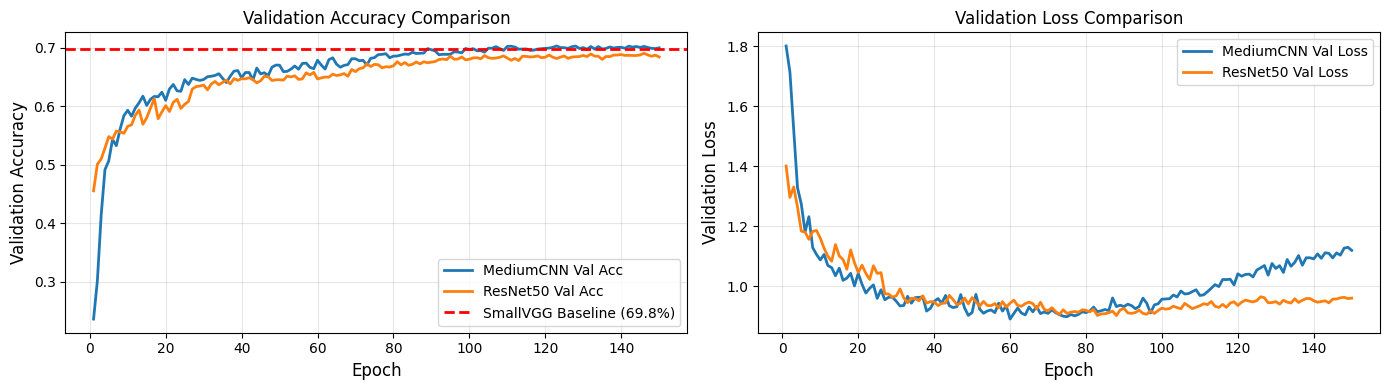

✓ Comparison plots saved


In [13]:
# Block 11: Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, EPOCHS + 1)

# Accuracy
axes[0].plot(epochs_range, history_medium['val_acc'], label='MediumCNN Val Acc', linewidth=2)
axes[0].plot(epochs_range, history_resnet['val_acc'], label='ResNet50 Val Acc', linewidth=2)
axes[0].axhline(y=0.698, color='r', linestyle='--', label='SmallVGG Baseline (69.8%)', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontsize=12)
axes[0].set_title('Validation Accuracy Comparison', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(epochs_range, history_medium['val_loss'], label='MediumCNN Val Loss', linewidth=2)
axes[1].plot(epochs_range, history_resnet['val_loss'], label='ResNet50 Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].set_title('Validation Loss Comparison', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_curves.png"), dpi=150)
plt.show()
print(f"✓ Comparison plots saved")

In [14]:
# Block 12: Detailed Evaluation (Best Model)
# Determine which model is best
best_model_name = "MediumCNN" if max(history_medium['val_acc']) >= max(history_resnet['val_acc']) else "ResNet50"
best_history = history_medium if best_model_name == "MediumCNN" else history_resnet

# Load best model
if best_model_name == "MediumCNN":
    best_model = MediumCNN(num_classes=NUM_CLASSES).to(DEVICE)
else:
    best_model = ResNet50Transfer(num_classes=NUM_CLASSES).to(DEVICE)
    
best_model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, f"{best_model_name}_best.pth"), map_location=DEVICE))
best_model.eval()

# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = best_model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print(f"\n{'='*60}")
print(f"📊 {best_model_name} - CLASSIFICATION REPORT")
print(f"{'='*60}")
class_names = sorted([d.name for d in Path(TEST_DIR).iterdir() if d.is_dir()])
report = classification_report(all_labels, all_preds, 
                              target_names=class_names,
                              digits=4)
print(report)

test_acc = (all_preds == all_labels).mean()
print(f"\n🎯 Overall {best_model_name} Test Accuracy: {test_acc:.4f}")


📊 MediumCNN - CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.6282    0.6420    0.6350       958
     disgust     0.6869    0.6126    0.6476       111
        fear     0.5951    0.5225    0.5564      1024
       happy     0.8810    0.8844    0.8827      1774
     neutral     0.6399    0.6845    0.6614      1233
         sad     0.5869    0.5798    0.5833      1247
    surprise     0.7986    0.8351    0.8165       831

    accuracy                         0.7033      7178
   macro avg     0.6881    0.6801    0.6833      7178
weighted avg     0.7014    0.7033    0.7018      7178


🎯 Overall MediumCNN Test Accuracy: 0.7033


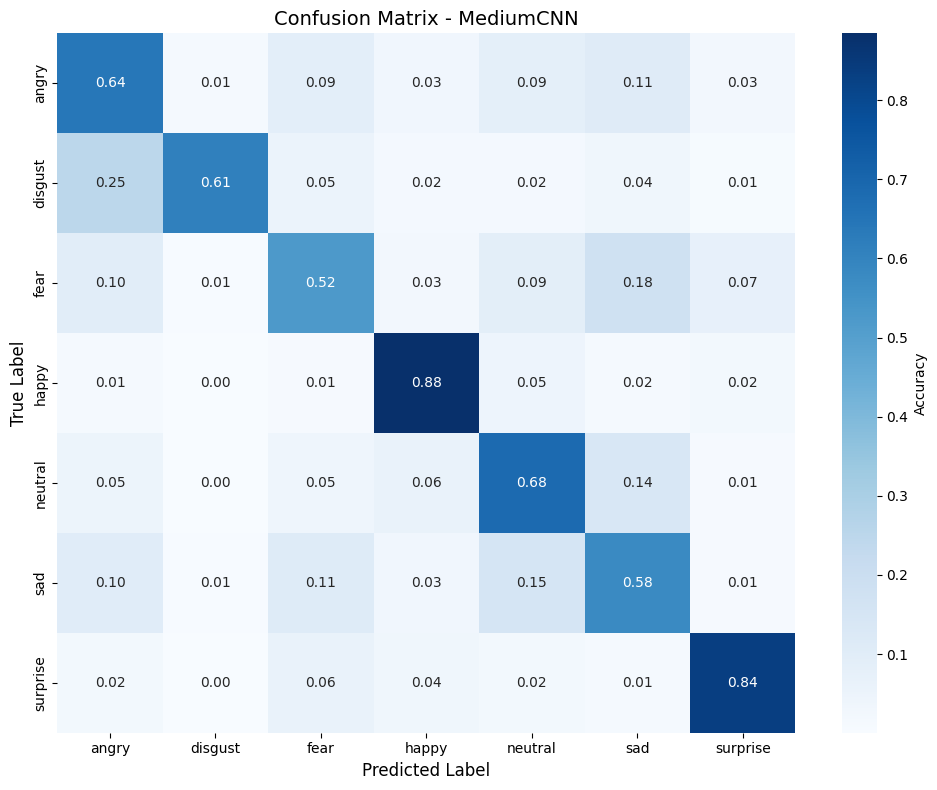

✓ Confusion matrix saved


In [15]:
# Block 13: Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Accuracy'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{best_model_name}_confusion_matrix.png"), dpi=150)
plt.show()
print(f"✓ Confusion matrix saved")

In [16]:
# Block 14: Summary
print("\n" + "="*60)
print("🏆 FINAL RESULTS")
print("="*60)

medium_best = max(history_medium['val_acc']) * 100
resnet_best = max(history_resnet['val_acc']) * 100

print(f"\nBaseline (SmallVGG):    69.80%")
print(f"MediumCNN:              {medium_best:.2f}%  {'✅ IMPROVED' if medium_best > 69.8 else '❌ Lower'}")
print(f"ResNet50 Transfer:      {resnet_best:.2f}%  {'✅ IMPROVED' if resnet_best > 69.8 else '❌ Lower'}")

winner = "MediumCNN" if medium_best >= resnet_best else "ResNet50"
winner_acc = max(medium_best, resnet_best)
improvement = winner_acc - 69.8

print(f"\n🏆 Best Model: {winner} at {winner_acc:.2f}%")
print(f"📈 Improvement over baseline: {improvement:+.2f}%")
print("="*60)


🏆 FINAL RESULTS

Baseline (SmallVGG):    69.80%
MediumCNN:              70.33%  ✅ IMPROVED
ResNet50 Transfer:      69.07%  ❌ Lower

🏆 Best Model: MediumCNN at 70.33%
📈 Improvement over baseline: +0.53%
